# Mastering Imperfect Information with Deep Recurrent Q-Networks
## Leduc Hold'em — DRQN vs DQN vs Baselines

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/DLPW/blob/master/notebooks/DLPW_colab.ipynb)

**This notebook trains and compares 4 agents:**

1. **DRQN** (Deep Recurrent Q-Network with LSTM memory)
2. **DQN** (Standard feedforward DQN - memoryless baseline)
3. **Random Agent** (baseline)
4. **Heuristic Agent** (rule-based baseline)

**Evaluations:**
- DRQN vs Random, Heuristic, DQN
- DQN vs Random, Heuristic
- **Total: 5 matchups**

**Runtime**: GPU recommended (~2-3 hours)

## 1. Setup & Installation

In [1]:
!pip install -q rlcard torch matplotlib

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Dependencies installed")
print(f"✓ Device: {device}")
print(f"✓ PyTorch version: {torch.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.0/269.0 kB 15.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✓ Dependencies installed
✓ Device: cuda
✓ PyTorch version: 2.10.0+cu128


## 2. Clone Repository

In [2]:
import os
import sys

# Clone repository (change YOUR_USERNAME)
!git clone https://github.com/Aghaei-Amirmasoud/DLPW.git
%cd DLPW

sys.path.insert(0, '/content/DLPW')
print("✓ Repository cloned and path configured")

Cloning into 'DLPW'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 76 (delta 29), reused 68 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (76/76), 409.73 KiB | 17.81 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/content/DLPW
✓ Repository cloned and path configured


## 3. Configuration

In [3]:
import config

# Adjust for Colab (increase for better results)
config.NUM_EPISODES_PHASE1 = 15000
config.NUM_EPISODES_PHASE2 = 15000

# Paths
config.OUTPUT_DIR = '/content/DLPW/outputs'
config.MODEL_DIR = '/content/DLPW/outputs/models'
config.PLOT_DIR = '/content/DLPW/outputs/plots'

os.makedirs(config.OUTPUT_DIR, exist_ok=True)
os.makedirs(config.MODEL_DIR, exist_ok=True)
os.makedirs(config.PLOT_DIR, exist_ok=True)

print("✓ Configuration set")
print(f"  Episodes per phase: {config.NUM_EPISODES_PHASE1}")
print(f"  Expected time: ~2-3 hours on GPU")

✓ Configuration set
  Episodes per phase: 15000
  Expected time: ~2-3 hours on GPU


## 4. Import Modules

In [ ]:
import rlcard
from rlcard.utils import set_seed
from rlcard.agents import RandomAgent, DQNAgent
import matplotlib.pyplot as plt
import numpy as np
import logging

from config import *
from agents import DRQNAgent, ConservativeHeuristicAgent
from training import CurriculumTrainer
from evaluation import (
    evaluate_agents,
    compute_action_distribution,
    print_evaluation_summary,
    print_advanced_analysis,
    compare_agents,
    statistical_significance,
    analyze_queen_play,
    analyze_round_performance,
    compare_queen_play
)
from analysis import plot_training_curves, plot_comparison_curves, plot_ev_comparison_bar

# Suppress RLCard INFO logs
logging.getLogger('rlcard').setLevel(logging.WARNING)

print("✓ All modules imported")

## 5. Environment Setup

In [5]:
set_seed(SEED)
env = rlcard.make(ENV_NAME)

raw_shape = env.state_shape[0]
state_shape = raw_shape[0] if isinstance(raw_shape, list) else raw_shape
num_actions = env.num_actions

print(f'✓ Environment: {ENV_NAME}')
print(f'✓ State shape: {state_shape}, Actions: {num_actions}')

✓ Environment: leduc-holdem
✓ State shape: 36, Actions: 4


In [ ]:
import os

# Create output directories if they don't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

print(f"✓ Directories ready:")
print(f"  {OUTPUT_DIR}")
print(f"  {MODEL_DIR}")
print(f"  {PLOT_DIR}")

## 6. Initialize Agents

In [6]:
# DRQN Agent (with LSTM memory)
agent_drqn = DRQNAgent(
    state_shape=state_shape,
    num_actions=num_actions,
    device=DEVICE,
    hidden_size=HIDDEN_SIZE,
    lr=LEARNING_RATE,
    gamma=GAMMA,
    epsilon_start=EPSILON_START,
    epsilon_min=EPSILON_MIN,
    epsilon_decay=EPSILON_DECAY,
    buffer_capacity=BUFFER_CAPACITY,
    batch_size=BATCH_SIZE,
    min_replay=MIN_REPLAY_SIZE,
    target_update_freq=TARGET_UPDATE_FREQ,
    l2_reg=L2_REGULARIZATION
)

# DQN Agent (feedforward baseline)
agent_dqn = DQNAgent(
    num_actions=num_actions,
    state_shape=env.state_shape[0],
    mlp_layers=[HIDDEN_SIZE, HIDDEN_SIZE],
    device=DEVICE
)

# Baseline agents
agent_random = RandomAgent(num_actions)
agent_heuristic = ConservativeHeuristicAgent(num_actions)

print("✓ All agents initialized")

✓ All agents initialized


## 7. Train DRQN (Two-Phase Curriculum)

**Phase 1**: Learn basic card strength against Random agent  
**Phase 2**: Learn exploitation against Heuristic agent

In [7]:
trainer_drqn = CurriculumTrainer(
    env=env,
    agent=agent_drqn,
    opponent_phase1=agent_random,
    opponent_phase2=agent_heuristic
)

drqn_history = trainer_drqn.train()

# Save model
agent_drqn.save_model(DRQN_CHECKPOINT)
print(f"\n✓ DRQN training complete. Model saved to {DRQN_CHECKPOINT}")

PHASE 1: Training vs Random Agent (0-15000)
[P1] Ep 00000 | ε=1.000 | EV vs Random: +1.261 | EV vs Heuristic: -0.991
[P1] Ep 01000 | ε=0.704 | EV vs Random: +1.058 | EV vs Heuristic: -0.557
[P1] Ep 02000 | ε=0.427 | EV vs Random: +1.091 | EV vs Heuristic: -0.652
[P1] Ep 03000 | ε=0.259 | EV vs Random: +0.913 | EV vs Heuristic: -0.546
[P1] Ep 04000 | ε=0.157 | EV vs Random: +0.942 | EV vs Heuristic: -0.479
[P1] Ep 05000 | ε=0.095 | EV vs Random: +0.976 | EV vs Heuristic: -0.587
[P1] Ep 06000 | ε=0.058 | EV vs Random: +0.935 | EV vs Heuristic: -0.619
[P1] Ep 07000 | ε=0.050 | EV vs Random: +0.947 | EV vs Heuristic: -0.234
[P1] Ep 08000 | ε=0.050 | EV vs Random: +1.058 | EV vs Heuristic: -0.295
[P1] Ep 09000 | ε=0.050 | EV vs Random: +0.905 | EV vs Heuristic: -0.242
[P1] Ep 10000 | ε=0.050 | EV vs Random: +1.053 | EV vs Heuristic: -0.374
[P1] Ep 11000 | ε=0.050 | EV vs Random: +0.978 | EV vs Heuristic: -0.469
[P1] Ep 12000 | ε=0.050 | EV vs Random: +0.952 | EV vs Heuristic: -0.557
[P1] Ep

## 8. Train DQN (Baseline Comparison)

In [8]:
trainer_dqn = CurriculumTrainer(
    env=env,
    agent=agent_dqn,
    opponent_phase1=agent_random,
    opponent_phase2=agent_heuristic
)

dqn_history = trainer_dqn.train()
print("\n✓ DQN training complete")

PHASE 1: Training vs Random Agent (0-15000)
[P1] Ep 00000 | ε=0.000 | EV vs Random: +0.398 | EV vs Heuristic: -0.171
INFO - Step 34, rl-loss: 3.5719878673553467
INFO - Copied model parameters to target network.
INFO - Step 626, rl-loss: 1.3388402462005615
INFO - Copied model parameters to target network.
INFO - Step 1191, rl-loss: 1.488452672958374
INFO - Copied model parameters to target network.
INFO - Step 1271, rl-loss: 0.43265074491500854[P1] Ep 01000 | ε=0.000 | EV vs Random: +1.087 | EV vs Heuristic: -0.950
INFO - Step 1757, rl-loss: 2.0213100910186768
INFO - Copied model parameters to target network.
INFO - Step 2317, rl-loss: 2.9020984172821045
INFO - Copied model parameters to target network.
INFO - Step 2566, rl-loss: 0.9274808168411255[P1] Ep 02000 | ε=0.000 | EV vs Random: +1.198 | EV vs Heuristic: -0.997
INFO - Step 2885, rl-loss: 1.3498945236206055
INFO - Copied model parameters to target network.
INFO - Step 3455, rl-loss: 1.850095510482788
INFO - Copied model parameter

## 9. Training Curves Visualization

Saved training curves to /content/DLPW/outputs/plots/drqn_training_curves.png


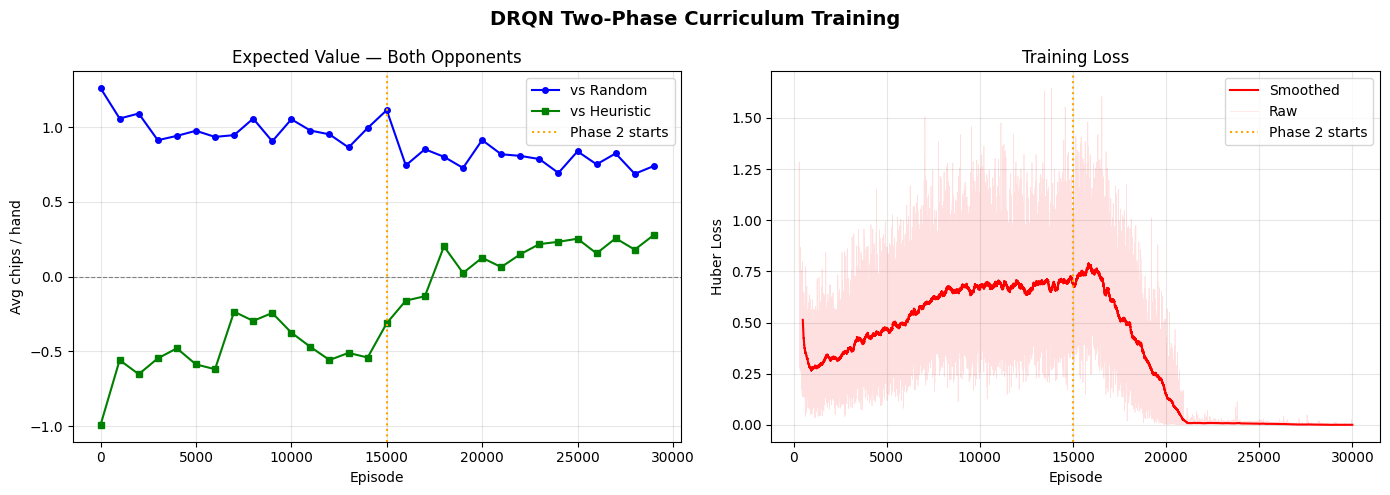

In [9]:
# DRQN training curves
plot_training_curves(
    ev_history_random=drqn_history['ev_random'],
    ev_history_heuristic=drqn_history['ev_heuristic'],
    loss_history=drqn_history['loss'],
    phase1_episodes=NUM_EPISODES_PHASE1,
    save_path=f'{PLOT_DIR}/drqn_training_curves.png'
)

## 12. Advanced Analysis

Detailed poker metrics including VPIP, aggression factor, and win rate by hand strength.

In [ ]:
# Advanced analysis for all matchups
print_advanced_analysis(results)

## 13. Head-to-Head Comparison: DRQN vs DQN

Direct comparison with playing style metrics.

In [ ]:
# Detailed DRQN vs DQN comparison
compare_agents(results, 'DRQN', 'DQN')

## 14. Statistical Significance Analysis

Verify the DRQN advantage is statistically robust.

## 15. Queen Play Investigation

Detailed analysis of the Queen misplay problem.

In [ ]:
# Compare how DRQN and DQN play Queens
compare_queen_play(results, 'DRQN', 'DQN')

## 16. Round Performance Analysis

Where do mistakes happen - Round 1 or Round 2?

In [ ]:
# Analyze round-specific performance
print("\n" + "="*60)
print("ROUND-BY-ROUND ANALYSIS")
print("="*60)

for agent_name in ['DRQN', 'DQN']:
    key = f'{agent_name} vs Heuristic'
    if key in results and 'trajectories' in results[key]:
        stats = analyze_round_performance(results[key]['trajectories'])
        
        print(f'\n{agent_name} vs Heuristic:')
        print(f"  Round 1 Folds: {stats.get('fold_round1_pct', 0):.1f}%")
        print(f"  Round 2 Folds: {stats.get('fold_round2_pct', 0):.1f}%")
        print(f"  Showdown Rate: {stats.get('showdown_pct', 0):.1f}%")
        
        if 'round1_aggressive_win_rate' in stats:
            print(f"  Round 1 Raise Success: {stats['round1_aggressive_win_rate']:.1f}%")
        if 'round2_aggressive_win_rate' in stats:
            print(f"  Round 2 Raise Success: {stats['round2_aggressive_win_rate']:.1f}%")

In [ ]:
# Statistical significance test
sig_test = statistical_significance(results['DRQN vs DQN']['ev'], NUM_EVAL_HANDS)

print("\n" + "="*60)
print("STATISTICAL SIGNIFICANCE TEST: DRQN vs DQN")
print("="*60)
print(f"\nExpected Value: {sig_test['ev']:+.3f} chips/hand")
print(f"Standard Error: ±{sig_test['std_error']:.3f}")
print(f"95% Confidence Interval: [{sig_test['ci_95_lower']:+.3f}, {sig_test['ci_95_upper']:+.3f}]")
print(f"Z-score: {sig_test['z_score']:.2f}")
print(f"P-value: {sig_test['p_value']:.6f}")
print(f"\nStatistically Significant (α=0.05): {'YES ✓' if sig_test['significant'] else 'NO'}")

if sig_test['significant']:
    print("\n" + "="*60)
    print("CONCLUSION: DRQN's memory advantage is STATISTICALLY ROBUST")
    print("="*60)
    print("The LSTM memory provides a significant competitive advantage")
    print("that cannot be attributed to random chance.")

Saved comparison curves to /content/DLPW/outputs/plots/drqn_vs_dqn_comparison.png


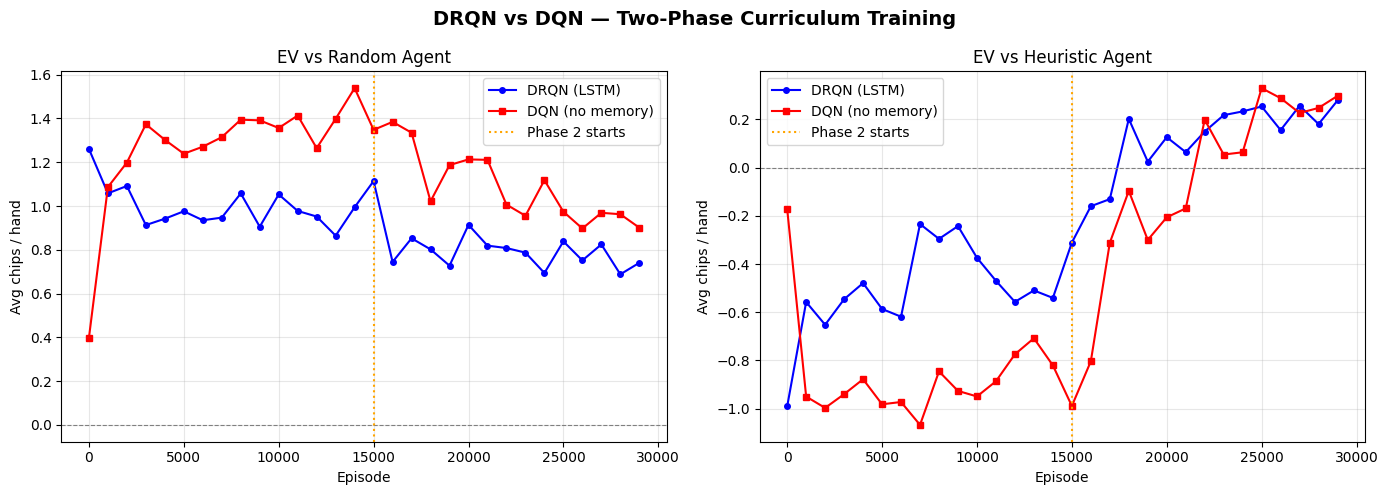

In [10]:
# DRQN vs DQN comparison
plot_comparison_curves(
    drqn_hist_random=drqn_history['ev_random'],
    drqn_hist_heuristic=drqn_history['ev_heuristic'],
    dqn_hist_random=dqn_history['ev_random'],
    dqn_hist_heuristic=dqn_history['ev_heuristic'],
    phase1_episodes=NUM_EPISODES_PHASE1,
    save_path=f'{PLOT_DIR}/drqn_vs_dqn_comparison.png'
)

## 10. Final Evaluation

In [11]:
print(f"\n{'='*60}")
print(f"FINAL EVALUATION ({NUM_EVAL_HANDS} hands per matchup)")
print(f"{'='*60}")

results = {}

# DRQN evaluations
print('\nDRQN vs ...')
ev_vs_random, traj_drqn_vs_random = evaluate_agents(
    env, agent_drqn, agent_random, NUM_EVAL_HANDS, 'Random'
)
ev_vs_heuristic, traj_drqn_vs_heuristic = evaluate_agents(
    env, agent_drqn, agent_heuristic, NUM_EVAL_HANDS, 'Heuristic'
)
ev_vs_dqn, traj_drqn_vs_dqn = evaluate_agents(
    env, agent_drqn, agent_dqn, NUM_EVAL_HANDS, 'Standard DQN'
)

# DQN evaluations
print('\nDQN vs ...')
dqn_vs_random, traj_dqn_vs_random = evaluate_agents(
    env, agent_dqn, agent_random, NUM_EVAL_HANDS, 'Random'
)
dqn_vs_heuristic, traj_dqn_vs_heuristic = evaluate_agents(
    env, agent_dqn, agent_heuristic, NUM_EVAL_HANDS, 'Heuristic'
)

# Store results
results['DRQN vs Random'] = {
    'ev': ev_vs_random,
    'trajectories': traj_drqn_vs_random,
    'action_stats': compute_action_distribution(traj_drqn_vs_random, ACTION_NAMES)
}
results['DRQN vs Heuristic'] = {
    'ev': ev_vs_heuristic,
    'trajectories': traj_drqn_vs_heuristic,
    'action_stats': compute_action_distribution(traj_drqn_vs_heuristic, ACTION_NAMES)
}
results['DRQN vs DQN'] = {
    'ev': ev_vs_dqn,
    'trajectories': traj_drqn_vs_dqn,
    'action_stats': compute_action_distribution(traj_drqn_vs_dqn, ACTION_NAMES)
}
results['DQN vs Random'] = {
    'ev': dqn_vs_random,
    'trajectories': traj_dqn_vs_random,
    'action_stats': compute_action_distribution(traj_dqn_vs_random, ACTION_NAMES)
}
results['DQN vs Heuristic'] = {
    'ev': dqn_vs_heuristic,
    'trajectories': traj_dqn_vs_heuristic,
    'action_stats': compute_action_distribution(traj_dqn_vs_heuristic, ACTION_NAMES)
}


FINAL EVALUATION (3000 hands per matchup)

DRQN vs ...
  Random                        : +0.864 chips/hand
  Heuristic                     : +0.243 chips/hand
  Standard DQN                  : +0.565 chips/hand

DQN vs ...
  Random                        : +0.841 chips/hand
  Heuristic                     : +0.465 chips/hand


## 11. Evaluation Summary & Analysis

In [12]:
# Detailed summary with action distributions and bluff rates
print_evaluation_summary(results)


FINAL EVALUATION SUMMARY

DRQN vs Random
----------------------------------------
  Expected Value: +0.864 chips/hand
  Action Distribution:
    Raise   :  3217 (43.4%)
    Call    :  2720 (36.7%)
    Fold    :  1172 (15.8%)
    Check   :   295 (4.0%)
  Bluff Rate (raise with Jack): 37.0%  (864/2335 decisions)

DRQN vs Heuristic
----------------------------------------
  Expected Value: +0.243 chips/hand
  Action Distribution:
    Raise   :  4366 (51.5%)
    Fold    :  3576 (42.2%)
    Call    :   533 (6.3%)
    Check   :     0 (0.0%)
  Bluff Rate (raise with Jack): 49.1%  (1458/2970 decisions)

DRQN vs DQN
----------------------------------------
  Expected Value: +0.565 chips/hand
  Action Distribution:
    Raise   :  6040 (57.5%)
    Fold    :  3184 (30.3%)
    Call    :   669 (6.4%)
    Check   :   619 (5.9%)
  Bluff Rate (raise with Jack): 57.5%  (1897/3301 decisions)

DQN vs Random
----------------------------------------
  Expected Value: +0.841 chips/hand
  Action Distribution

Saved EV comparison to outputs/plots/ev_comparison.png


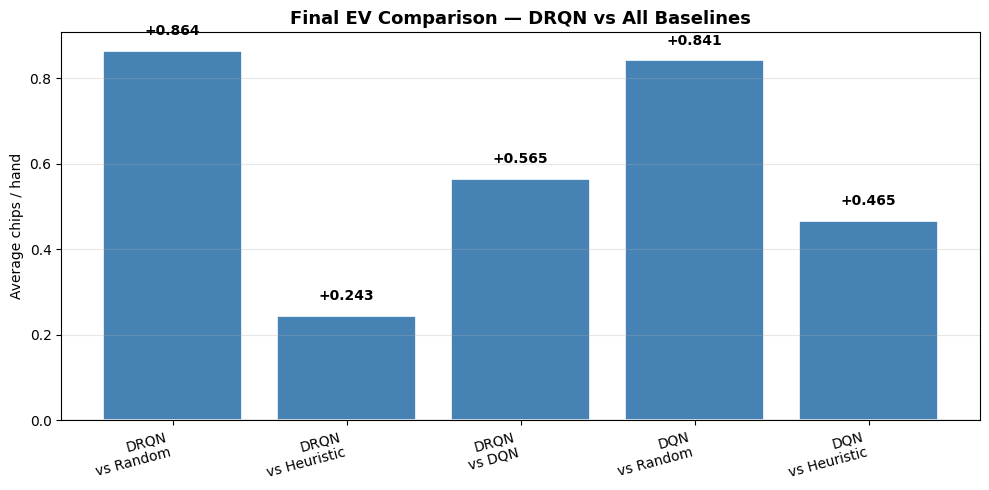

In [13]:
# EV comparison bar chart
ev_comparison = {
    'DRQN\nvs Random': results['DRQN vs Random']['ev'],
    'DRQN\nvs Heuristic': results['DRQN vs Heuristic']['ev'],
    'DRQN\nvs DQN': results['DRQN vs DQN']['ev'],
    'DQN\nvs Random': results['DQN vs Random']['ev'],
    'DQN\nvs Heuristic': results['DQN vs Heuristic']['ev'],
}
plot_ev_comparison_bar(
    results=ev_comparison,
    save_path=EV_COMPARISON_PLOT
)